# Causal Discovery Agent - Graph Visualization

This notebook visualizes the directed graph of the autonomous causal discovery agent using LangGraph and Mermaid.


In [1]:
# Import required libraries
import sys
import os
from pathlib import Path
from IPython.display import Image, display, Markdown

# Add the cryptosentinel directory to the path
project_root = Path.cwd()
cryptosentinel_path = project_root / "cryptosentinel"
if str(cryptosentinel_path) not in sys.path:
    sys.path.insert(0, str(cryptosentinel_path))

print(f"Project root: {project_root}")
print(f"CryptoSentinel path: {cryptosentinel_path}")
print(f"Python path includes: {cryptosentinel_path.exists()}")


Project root: /Users/khoadangnguyen/Desktop/confluent_ai_catalyst/cryptosentinel
CryptoSentinel path: /Users/khoadangnguyen/Desktop/confluent_ai_catalyst/cryptosentinel/cryptosentinel
Python path includes: False


In [2]:
# Import the agent
from agent.orchestrator import CausalDiscoveryAgent
from config.settings import get_settings

print("✅ Successfully imported CausalDiscoveryAgent")


✅ Successfully imported CausalDiscoveryAgent


/Users/khoadangnguyen/Desktop/confluent_ai_catalyst/cryptosentinel/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/khoadangnguyen/Desktop/confluent_ai_catalyst/cryptosentinel/agent/data_discovery.py:7: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [3]:
# Initialize the agent
print("📦 Initializing agent...")

import dotenv
from pathlib import Path

env_path = Path('.') / '.env'
if env_path.exists():
    print("✅ .env file found at project root.")
else:
    print("⚠️  .env file not found at project root - attempting to load environment variables anyway.")

# Attempt to load the .env file if present to make environment variables available
dotenv.load_dotenv(dotenv_path=env_path, override=True)

from config.settings import Settings

# Now try to get settings using the actual get_settings() function
try:
    from config.settings import get_settings
    settings = get_settings()
    print("✅ Loaded settings from get_settings (using env/ENV vars)")
except Exception as e:
    print(f"⚠️  get_settings() failed: {e}")
    print("   Attempting to construct Settings manually from environment variables...")

    # Construct Settings from environment variables directly
    settings = Settings(
        kafka_bootstrap_servers=os.getenv("KAFKA_BOOTSTRAP_SERVERS", ""),
        kafka_api_key=os.getenv("KAFKA_API_KEY", ""),
        kafka_api_secret=os.getenv("KAFKA_API_SECRET", ""),
        schema_registry_url=os.getenv("SCHEMA_REGISTRY_URL", ""),
        schema_registry_api_key=os.getenv("SCHEMA_REGISTRY_API_KEY", ""),
        schema_registry_api_secret=os.getenv("SCHEMA_REGISTRY_API_SECRET", ""),
        gemini_api_key=os.getenv("GEMINI_API_KEY", ""),
        reddit_client_id=os.getenv("REDDIT_CLIENT_ID", ""),
        reddit_client_secret=os.getenv("REDDIT_CLIENT_SECRET", ""),
    )
    print("✅ Created mock settings from os.environ for visualization")

try:
    agent = CausalDiscoveryAgent(settings)
    print("✅ Agent initialized successfully!")
    print(f"   Graph available: {agent.graph is not None}")
    print(f"   App compiled: {agent.app is not None}")
except Exception as e:
    print(f"❌ Error initializing agent: {e}")
    import traceback
    traceback.print_exc()


📦 Initializing agent...
✅ .env file found at project root.
✅ Loaded settings from get_settings (using env/ENV vars)
✅ Agent initialized successfully!
   Graph available: True
   App compiled: True


✅ Retrieved graph from compiled app


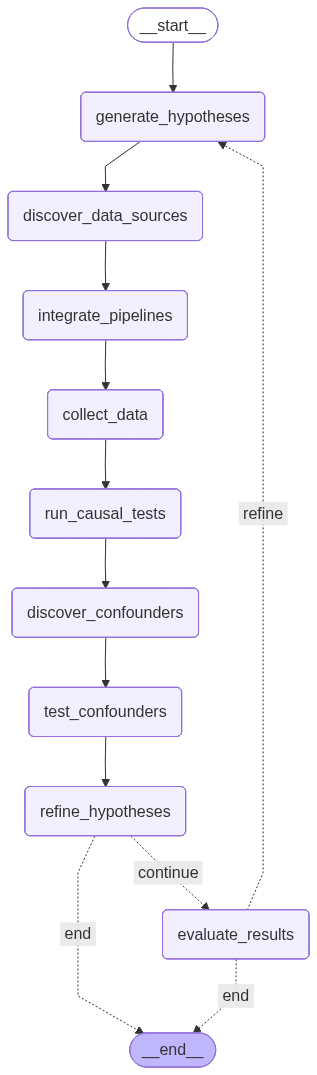

✅ Displayed graph using draw_mermaid_png()


In [4]:
# Get the graph and visualize it
if agent.graph is not None:
    try:
        # Get the graph object (LangGraph provides get_graph() method)
        # The graph can be accessed from the compiled app or directly
        if agent.app is not None:
            # Try to get graph from compiled app
            try:
                graph_obj = agent.app.get_graph()
                print("✅ Retrieved graph from compiled app")
            except AttributeError:
                # Fallback: use the graph directly
                graph_obj = agent.graph
                print("✅ Using graph directly")
        else:
            graph_obj = agent.graph
            print("✅ Using graph directly (app not compiled)")
        
        # Generate mermaid visualization
        try:
            # Method 1: Try draw_mermaid_png() (returns PNG bytes)
            mermaid_png = graph_obj.draw_mermaid_png()
            display(Image(mermaid_png))
            print("✅ Displayed graph using draw_mermaid_png()")
        except AttributeError:
            try:
                # Method 2: Try draw_mermaid() (returns mermaid string)
                mermaid_str = graph_obj.draw_mermaid()
                display(Markdown(f"```mermaid\n{mermaid_str}\n```"))
                print("✅ Displayed graph using draw_mermaid()")
            except AttributeError:
                # Method 3: Try get_graph().draw_mermaid_png()
                try:
                    if hasattr(graph_obj, 'get_graph'):
                        inner_graph = graph_obj.get_graph()
                        mermaid_png = inner_graph.draw_mermaid_png()
                        display(Image(mermaid_png))
                        print("✅ Displayed graph using get_graph().draw_mermaid_png()")
                    else:
                        raise AttributeError("No get_graph method")
                except (AttributeError, Exception) as e:
                    print(f"⚠️  Could not use standard visualization methods: {e}")
                    print("   Attempting alternative visualization...")
                    # Fallback: Print graph structure
                    print(f"\nGraph type: {type(graph_obj)}")
                    print(f"Graph methods: {[m for m in dir(graph_obj) if not m.startswith('_')]}")
                    
    except Exception as e:
        print(f"❌ Error visualizing graph: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️  Graph is None - LangGraph may not be available or graph not built")
